# Tahap 5 - Model Evaluation
## CBR Putusan Wanprestasi PN Surabaya

**Tujuan :** Ukur dan analisis performa retrieval & prediksi.

**Input:**
- `data/processed/cases.csv` -> case base final (Tahap 2, sudah melewati Tahap 3/4, retain jika ada)
- `data/eval/queries.json` -> 5-10 query uji + ground-truth case_id (Tahap 3)
- `data/results/predictions.csv` -> hasil demo `predict_outcome()` (Tahap 4)

**Output (sesuai soal poin e.iii):**
- `data/eval/retrieval_metrics.csv`
- `data/eval/prediction_metrics.csv`
- Bagian evaluasi lengkap (tabel, grafik, error analysis) di notebook ini

---

## Alur Tahap 5

| Cell | Fungsi |
|---|---|
| **Cell 1** | Import library & install dependensi |
| **Cell 2** | Load `cases.csv`, bangun ulang TF-IDF + `retrieve()` (identik Tahap 3) |
| **Cell 3** | Bangun ulang model klasifikasi SVM (identik Tahap 3) untuk perbandingan TF-IDF vs SVM |
| **Cell 4** | Load `queries.json` (ground truth retrieval) |
| **Cell 5** | **`eval_retrieval(queries, ground_truth, k)`** — Accuracy/Precision/Recall/F1 retrieval |
| **Cell 6** | Evaluasi **prediksi** (`predict_outcome` / SVM) — `eval_prediction()` |
| **Cell 7** | Tabel metrik per model (TF-IDF Retrieval vs SVM vs Weighted-CBR) |
| **Cell 8** | Plot bar chart perbandingan performa |
| **Cell 9** | Error Analysis — kasus kegagalan & rekomendasi perbaikan |
| **Cell 10** | Simpan `retrieval_metrics.csv` & `prediction_metrics.csv` |
| **Cell 11** | Ringkasan akhir Tahap 5 |

## Setup - Jangkar Working Directory ke Root Repository

**Jalankan cell ini SELALU sebagai cell pertama**, sebelum cell lain di notebook ini.

Notebook ini disimpan di dalam folder `notebooks/`, tapi seluruh path data di notebook ini
(mis. `'data/processed/cases.csv'`) ditulis **relatif terhadap root repository**, bukan terhadap
folder `notebooks/`. Secara default, Jupyter menjalankan kernel dengan *working directory* = folder
tempat file `.ipynb` itu sendiri berada. Tanpa cell ini, path seperti `'data/raw'` akan dicari di
`notebooks/data/raw` (tidak ada) dan menyebabkan `FileNotFoundError`.

Cell ini **aman dijalankan berkali-kali** (idempotent) — begitu working directory sudah berada di
root repository (folder yang punya subfolder `data/`), cell ini tidak akan berpindah lagi.

In [1]:
import os

# Jika folder 'data/' tidak ada di working directory saat ini, TAPI ada satu
# level di atasnya -> kita sedang di dalam notebooks/, pindah ke root repo.
if not os.path.isdir('data') and os.path.isdir(os.path.join('..', 'data')):
    os.chdir('..')

print('Working directory aktif :', os.getcwd())
print('Isi folder saat ini     :', sorted(os.listdir('.')))

assert os.path.isdir('data'), (
    "Folder 'data/' tidak ditemukan dari working directory ini.\n"
    "Pastikan struktur repo: <root>/notebooks/xx.ipynb dengan <root>/data/ di sebelahnya,\n"
    "dan notebook dibuka dari dalam struktur repo tersebut (bukan dipindah sendirian)."
)


Working directory aktif : c:\Users\LENOVO\Documents\Penalaran Komputer\Tugas_3\Tugas3.1
Isi folder saat ini     : ['.git', '.gitignore', 'README.md', 'data', 'logs', 'notebooks', 'requirements.txt']


## Cell 1 - Import Library

In [2]:
import subprocess, sys
for pkg in ['scikit-learn', 'pandas', 'numpy', 'matplotlib']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], capture_output=True)

import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

os.makedirs('data/eval', exist_ok=True)

print('Library siap! (scikit-learn untuk seluruh metrik: accuracy_score, precision_score,')
print('recall_score, f1_score, confusion_matrix, classification_report)')

Library siap! (scikit-learn untuk seluruh metrik: accuracy_score, precision_score,
recall_score, f1_score, confusion_matrix, classification_report)


## Cell 2 - Load `cases.csv` & Bangun Ulang TF-IDF + `retrieve()`

Dibangun ulang dengan konfigurasi **identik Tahap 3** (`max_features=5000, ngram_range=(1,2),
min_df=2, max_df=0.95, sublinear_tf=True`) agar notebook ini dapat dijalankan independen.

In [3]:
PATH_CASES_CSV       = 'data/processed/cases.csv'
PATH_QUERIES_JSON    = 'data/eval/queries.json'
PATH_PREDICTIONS_CSV = 'data/results/predictions.csv'
PATH_RETRIEVAL_OUT   = 'data/eval/retrieval_metrics.csv'
PATH_PREDICTION_OUT  = 'data/eval/prediction_metrics.csv'

df = pd.read_csv(PATH_CASES_CSV, encoding='utf-8-sig')
df = df[df['text_full'].notna() & (df['text_full'].str.len() > 100)].reset_index(drop=True)
df = df[df['label_putusan'].isin([0, 1])].reset_index(drop=True)  # konsisten Tahap 3/4

LABEL_NAMA = {1: 'Dikabulkan', 0: 'Ditolak/NO'}

print('=' * 62)
print('  KONFIGURASI TAHAP 5 — MODEL EVALUATION')
print('=' * 62)
print(f'  Total kasus (case base)  : {len(df)}')
print(f'  Label Dikabulkan (1)     : {(df["label_putusan"]==1).sum()}')
print(f'  Label Ditolak/NO (0)     : {(df["label_putusan"]==0).sum()}')
print('=' * 62)

  KONFIGURASI TAHAP 5 — MODEL EVALUATION
  Total kasus (case base)  : 54
  Label Dikabulkan (1)     : 30
  Label Ditolak/NO (0)     : 24


In [4]:
STOPWORDS = {
    'dan', 'di', 'ke', 'dari', 'yang', 'ini', 'itu', 'atau',
    'pada', 'dengan', 'adalah', 'juga', 'oleh', 'serta', 'pula',
    'pun', 'nya', 'si', 'tidak', 'telah', 'akan', 'bahwa', 'untuk',
    'dalam', 'atas', 'tersebut', 'para', 'sebagai', 'sudah',
    'hal', 'maka', 'agar', 'karena', 'namun', 'tetapi', 'jika',
    'pihak', 'perkara', 'maupun', 'dapat', 'saat',
}

def preprocess_query(teks: str) -> str:
    """Preprocessing identik Tahap 3/4: lowercase, hapus tanda baca, filter stopwords."""
    teks = teks.lower()
    teks = re.sub(r'[^\w\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    tokens = [t for t in teks.split() if t not in STOPWORDS and len(t) >= 3]
    return ' '.join(tokens)


corpus   = df['text_full'].apply(preprocess_query).tolist()
case_ids = df['case_id'].tolist()

vectorizer = TfidfVectorizer(
    max_features=5000, min_df=2, max_df=0.95,
    ngram_range=(1, 2), sublinear_tf=True,
)
tfidf_matrix = vectorizer.fit_transform(corpus)


def retrieve(query: str, k: int = 5) -> List[str]:
    """Temukan k kasus paling mirip dengan query. (Identik Tahap 3)"""
    query_vec  = vectorizer.transform([preprocess_query(query)])
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_k_idx  = np.argsort(sim_scores)[::-1][:k]
    return [case_ids[i] for i in top_k_idx]


def retrieve_with_scores(query: str, k: int = 5) -> List[dict]:
    """Versi retrieve() dengan skor similarity & label. (Identik Tahap 3/4)"""
    query_vec  = vectorizer.transform([preprocess_query(query)])
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_k_idx  = np.argsort(sim_scores)[::-1][:k]
    hasil = []
    for i in top_k_idx:
        row = df.iloc[i]
        hasil.append({
            'case_id': case_ids[i], 'no_perkara': row['no_perkara'],
            'similarity': round(float(sim_scores[i]), 4),
            'label': int(row['label_putusan']),
        })
    return hasil


print(f'TF-IDF matrix dibangun ulang: {tfidf_matrix.shape[0]} dokumen x {tfidf_matrix.shape[1]:,} fitur')
print('Fungsi retrieve() & retrieve_with_scores() siap.')

TF-IDF matrix dibangun ulang: 54 dokumen x 5,000 fitur
Fungsi retrieve() & retrieve_with_scores() siap.


## Cell 3 - Bangun Ulang Model Klasifikasi SVM (untuk Perbandingan TF-IDF vs SVM)

Soal poin **e.ii.1** meminta *"Tabel metrik per model (Misal: TF-IDF vs. BERT vs. SVM)"*.
Dataset ini memakai pendekatan **TF-IDF + SVM** (sesuai Tahap 3), jadi perbandingan yang
relevan adalah:
- **TF-IDF Retrieval (cosine similarity)** — Tahap 3/4, dipakai `retrieve()` & CBR
- **SVM Classifier (atas representasi TF-IDF)** — model klasifikasi langsung label
- **CBR Weighted-Similarity** — `predict_outcome()` Tahap 4, retrieval + voting

In [5]:
X = tfidf_matrix
y = df['label_putusan'].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
)

svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print('=' * 62)
print('  MODEL SVM (atas representasi TF-IDF) — DIBANGUN ULANG')
print('=' * 62)
print(f'  Data latih  : {X_train.shape[0]} dokumen')
print(f'  Data uji    : {X_test.shape[0]} dokumen')
print(f'  Kernel      : linear')
print()
print(classification_report(y_test, y_pred_svm, target_names=['Ditolak/NO (0)', 'Dikabulkan (1)'], zero_division=0))

  MODEL SVM (atas representasi TF-IDF) — DIBANGUN ULANG
  Data latih  : 43 dokumen
  Data uji    : 11 dokumen
  Kernel      : linear

                precision    recall  f1-score   support

Ditolak/NO (0)       0.50      0.20      0.29         5
Dikabulkan (1)       0.56      0.83      0.67         6

      accuracy                           0.55        11
     macro avg       0.53      0.52      0.48        11
  weighted avg       0.53      0.55      0.49        11



## Cell 4 - Load `queries.json` (Ground Truth Retrieval)

Jika `data/eval/queries.json` dari Tahap 3 belum ada / jumlahnya kurang dari 5,
dibuat otomatis dari `ringkasan_fakta` 8 kasus acak di case base (metode **leave-one-out**
— kasus sumber dikecualikan saat retrieval, ground truth = `case_id` aslinya), supaya
notebook tetap dapat dievaluasi end-to-end.

In [6]:
def buat_queries_otomatis(df_case_base, n_query=8, seed=42):
    """
    Membuat queries.json otomatis dari ringkasan_fakta kasus acak di case base.
    Setiap query memakai potongan ringkasan_fakta sebagai teks uji, dengan
    ground-truth sebagai LIST berisi 1 case_id (konsisten dengan format
    ground_truth Tahap 3, yang mendukung beberapa case_id relevan per query).
    """
    rng = np.random.default_rng(seed)
    idx_sample = rng.choice(len(df_case_base), size=min(n_query, len(df_case_base)), replace=False)
    queries = []
    for i, idx in enumerate(idx_sample, start=1):
        row = df_case_base.iloc[idx]
        fakta = str(row.get('ringkasan_fakta', '')).strip()
        query_text = fakta[:400] if len(fakta) > 50 else str(row['text_full'])[:400]
        queries.append({
            'query_id'       : f'Q{i:03d}',
            'query'          : query_text,
            'ground_truth'   : [row['case_id']],   # LIST, konsisten dengan format Tahap 3
            'ground_truth_label': int(row['label_putusan']),
        })
    return queries


def normalisasi_ground_truth(gt) -> list:
    """
    Pastikan ground_truth selalu berbentuk list[str], apapun bentuk aslinya
    di queries.json (bisa string tunggal dari versi lama, atau list dari
    Tahap 3). Ini membuat Tahap 5 kompatibel dengan kedua format.
    """
    if isinstance(gt, list):
        return [str(g) for g in gt]
    if gt is None:
        return []
    return [str(gt)]


if os.path.exists(PATH_QUERIES_JSON):
    with open(PATH_QUERIES_JSON, 'r', encoding='utf-8') as f:
        queries = json.load(f)
    print(f'queries.json dimuat dari Tahap 3: {len(queries)} query')

    # Normalisasi: pastikan ground_truth selalu list (bisa berisi >=0 case_id)
    for q in queries:
        q['ground_truth'] = normalisasi_ground_truth(q.get('ground_truth'))

    # Validasi: pastikan ground_truth tidak kosong DAN minimal 1 case_id-nya
    # masih ada di case base saat ini (case base bisa berubah karena retain)
    valid_ids = set(df['case_id'])
    queries_valid = []
    for q in queries:
        gt_masih_ada = [c for c in q['ground_truth'] if c in valid_ids]
        if len(gt_masih_ada) > 0:
            q['ground_truth'] = gt_masih_ada
            queries_valid.append(q)
    queries = queries_valid
    print(f'   -> {len(queries)} query valid (>=1 ground_truth ada di case base saat ini)')
else:
    queries = []

if len(queries) < 5:
    print('queries.json tidak ditemukan / kurang dari 5 query valid -> dibuat otomatis dari case base.')
    queries = buat_queries_otomatis(df, n_query=8)
    os.makedirs('data/eval', exist_ok=True)
    with open(PATH_QUERIES_JSON, 'w', encoding='utf-8') as f:
        json.dump(queries, f, ensure_ascii=False, indent=2)
    print(f'{len(queries)} query otomatis disimpan ke {PATH_QUERIES_JSON}')

print()
print(f'Total query uji untuk evaluasi: {len(queries)}')
for q in queries[:3]:
    print(f"  [{q['query_id']}] ground_truth={q['ground_truth']} | {q['query'][:70]}...")


queries.json dimuat dari Tahap 3: 8 query
   -> 8 query valid (>=1 ground_truth ada di case base saat ini)

Total query uji untuk evaluasi: 8
  [Q001] ground_truth=['case_001', 'case_003', 'case_005'] | tergugat wanprestasi tidak membayar hutang sesuai perjanjian kredit...
  [Q002] ground_truth=['case_002', 'case_004', 'case_007'] | gugatan penggugat ditolak eksepsi dikabulkan tidak dapat diterima...
  [Q003] ground_truth=['case_001', 'case_003', 'case_005'] | perjanjian jual beli tanah bangunan tergugat ingkar janji tidak menyer...


## Cell 5 - `eval_retrieval(queries, ground_truth, k)`

Sesuai soal poin **e.i** & **f.i**: ukur **Accuracy, Precision, Recall, F1-score** dari hasil
retrieval menggunakan `sklearn.metrics`, dan implementasikan sebagai fungsi
`eval_retrieval(queries, ground_truth, k)` (struktur identik soal 05_evaluation.py).

**Definisi metrik pada konteks retrieval top-k (per query):**
- **Hit (relevan ditemukan)** = `ground_truth case_id` muncul di antara top-k hasil `retrieve()`
- **Accuracy** = proporsi query yang "hit" dari total query (Hit Rate@k)
- **Precision@k** = `1/k` jika hit (1 dokumen relevan dari k slot), `0` jika tidak hit
- **Recall@k** = `1` jika hit (1 dari 1 dokumen relevan ground truth ditemukan), `0` jika tidak
- **F1-score@k** = harmonic mean dari Precision@k dan Recall@k

Karena setiap query di `queries.json` punya **tepat satu** `ground_truth case_id` (bukan label
kelas multi), metrik dihitung di level **dokumen relevan/tidak relevan** (binary hit/miss)
menggunakan `sklearn.metrics.precision_score` / `recall_score` / `f1_score` dengan
`average='binary'` atas vektor hit/miss seluruh query — bukan label klasifikasi 0/1 amar putusan
(itu dievaluasi terpisah di Cell 6, sesuai soal poin **f.i**: *"apabila tersedia label hasil putusan"*).

In [7]:
def eval_retrieval(queries: List[dict], ground_truth_key: str = 'ground_truth', k: int = 5) -> dict:
    """
    Evaluasi performa fungsi retrieve() — Precision/Recall/F1 multi-relevan
    per query (konsisten dengan pendekatan ground_truth = List[case_id] di
    Tahap 3, BUKAN hit/miss biner satu-vs-satu).

    Args:
        queries           : List[dict] -- tiap dict berisi 'query' & ground_truth_key
        ground_truth_key  : str  -- nama field ground truth (selalu list[str])
        k                 : int  -- top-k yang dipertimbangkan

    Returns:
        dict -- accuracy (rata2 query dgn >=1 hit), precision/recall/f1
                rata-rata makro, dan detail per-query.
    """
    detail = []
    precisions, recalls, f1s, ada_hit = [], [], [], []

    for q in queries:
        gt_set       = set(q[ground_truth_key])
        top_k_result = retrieve(q['query'], k=k)
        retrieved_set = set(top_k_result)

        tp        = len(gt_set & retrieved_set)
        precision = tp / len(retrieved_set) if retrieved_set else 0
        recall    = tp / len(gt_set)        if gt_set        else 0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0)
        hit       = 1 if tp > 0 else 0

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        ada_hit.append(hit)

        detail.append({
            'query_id'      : q.get('query_id', '-'),
            'ground_truth'  : sorted(gt_set),
            'top_k_result'  : top_k_result,
            'tp'            : tp,
            'precision'     : round(precision, 4),
            'recall'        : round(recall, 4),
            'f1'            : round(f1, 4),
            'hit'           : bool(hit),
        })

    n = len(queries)
    return {
        'k'         : k,
        'n_queries' : n,
        'accuracy'  : round(sum(ada_hit) / n, 4) if n else 0,   # proporsi query dgn >=1 hit
        'precision' : round(sum(precisions) / n, 4) if n else 0,
        'recall'    : round(sum(recalls) / n, 4) if n else 0,
        'f1_score'  : round(sum(f1s) / n, 4) if n else 0,
        'detail'    : detail,
    }


# ── Jalankan evaluasi retrieval untuk k=5 (sesuai default Tahap 3/4) ─────────
hasil_retrieval = eval_retrieval(queries, ground_truth_key='ground_truth', k=5)

print('=' * 62)
print('  HASIL eval_retrieval() — TF-IDF Retrieval (k=5)')
print('=' * 62)
print(f'  Jumlah query   : {hasil_retrieval["n_queries"]}')
print(f'  Accuracy@5     : {hasil_retrieval["accuracy"]:.4f}  (proporsi query dgn >=1 ground-truth ditemukan)')
print(f'  Precision@5    : {hasil_retrieval["precision"]:.4f}  (rata-rata makro)')
print(f'  Recall@5       : {hasil_retrieval["recall"]:.4f}  (rata-rata makro)')
print(f'  F1-score@5     : {hasil_retrieval["f1_score"]:.4f}  (rata-rata makro)')
print('=' * 62)
print()
print('Detail per query:')
for d in hasil_retrieval['detail']:
    status = f"HIT ({d['tp']}/{len(d['ground_truth'])})" if d['hit'] else 'MISS'
    print(f"  [{d['query_id']}] GT={d['ground_truth']} -> {status:<14} P={d['precision']:.2f} R={d['recall']:.2f} F1={d['f1']:.2f}")


  HASIL eval_retrieval() — TF-IDF Retrieval (k=5)
  Jumlah query   : 8
  Accuracy@5     : 0.6250  (proporsi query dgn >=1 ground-truth ditemukan)
  Precision@5    : 0.1500  (rata-rata makro)
  Recall@5       : 0.2500  (rata-rata makro)
  F1-score@5     : 0.1875  (rata-rata makro)

Detail per query:
  [Q001] GT=['case_001', 'case_003', 'case_005'] -> HIT (1/3)      P=0.20 R=0.33 F1=0.25
  [Q002] GT=['case_002', 'case_004', 'case_007'] -> HIT (1/3)      P=0.20 R=0.33 F1=0.25
  [Q003] GT=['case_001', 'case_003', 'case_005'] -> MISS           P=0.00 R=0.00 F1=0.00
  [Q004] GT=['case_005', 'case_006', 'case_009'] -> MISS           P=0.00 R=0.00 F1=0.00
  [Q005] GT=['case_001', 'case_003', 'case_012'] -> MISS           P=0.00 R=0.00 F1=0.00
  [Q006] GT=['case_004', 'case_010', 'case_011'] -> HIT (1/3)      P=0.20 R=0.33 F1=0.25
  [Q007] GT=['case_001', 'case_005', 'case_012'] -> HIT (2/3)      P=0.40 R=0.67 F1=0.50
  [Q008] GT=['case_001', 'case_003', 'case_009'] -> HIT (1/3)      P=0.20 R=0

In [8]:
# ── Uji sensitivitas terhadap nilai k (k=1, 3, 5, 10) ────────────────────────
hasil_per_k = []
for k_val in [1, 3, 5, 10]:
    r = eval_retrieval(queries, ground_truth_key='ground_truth', k=k_val)
    hasil_per_k.append({
        'k': k_val, 'accuracy': r['accuracy'], 'precision': r['precision'],
        'recall': r['recall'], 'f1_score': r['f1_score'],
    })

df_per_k = pd.DataFrame(hasil_per_k)
print('Perbandingan performa retrieval pada berbagai nilai k:')
print(df_per_k.to_string(index=False))

Perbandingan performa retrieval pada berbagai nilai k:
 k  accuracy  precision  recall  f1_score
 1     0.125     0.1250  0.0417    0.0625
 3     0.500     0.1667  0.1667    0.1667
 5     0.625     0.1500  0.2500    0.1875
10     0.875     0.1375  0.4583    0.2115


## Cell 6 - Evaluasi Prediksi (Klasifikasi Label Putusan)

Soal poin **f.i**: *"apabila tersedia label hasil putusan"* — karena `label_putusan` tersedia
di `cases.csv`, evaluasi klasifikasi dilakukan untuk **2 pendekatan**:
1. **CBR (`predict_outcome` / weighted-similarity)** — dari hasil demo Tahap 4 (`predictions.csv`)
2. **SVM Classifier langsung** — dari Cell 3 (held-out test set)

Metrik: **Accuracy, Precision (macro), Recall (macro), F1-score (macro)** — `average='macro'`
dipakai karena ini klasifikasi biner dengan kelas yang relatif seimbang (Dikabulkan/Ditolak).

In [9]:
def eval_prediction(y_true: list, y_pred: list, nama_model: str) -> dict:
    """
    Evaluasi performa klasifikasi/prediksi label putusan menggunakan sklearn.metrics.

    Args:
        y_true     : list -- label sebenarnya (dari putusan asli)
        y_pred     : list -- label hasil prediksi model
        nama_model : str  -- nama model untuk pelaporan

    Returns:
        dict -- accuracy, precision, recall, f1 (macro-average) + confusion matrix
    """
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm        = confusion_matrix(y_true, y_pred, labels=[0, 1])

    return {
        'model'     : nama_model,
        'n_samples' : len(y_true),
        'accuracy'  : round(accuracy, 4),
        'precision' : round(precision, 4),
        'recall'    : round(recall, 4),
        'f1_score'  : round(f1, 4),
        'confusion_matrix': cm.tolist(),
    }


# ── 1) Evaluasi SVM (held-out test set dari Cell 3) ──────────────────────────
metrik_svm = eval_prediction(y_test, y_pred_svm, 'SVM (TF-IDF)')

# ── 2) Evaluasi CBR predict_outcome() dari predictions.csv Tahap 4 ───────────
if os.path.exists(PATH_PREDICTIONS_CSV):
    df_pred = pd.read_csv(PATH_PREDICTIONS_CSV, encoding='utf-8-sig')
    y_true_cbr = df_pred['label_sebenarnya'].tolist()
    y_pred_cbr = df_pred['predicted_label'].tolist()
    metrik_cbr = eval_prediction(y_true_cbr, y_pred_cbr, 'CBR (predict_outcome - weighted)')
    print(f'predictions.csv dimuat dari Tahap 4: {len(df_pred)} kasus demo')
else:
    print('predictions.csv tidak ditemukan -> metrik CBR dilewati (cek path Tahap 4).')
    metrik_cbr = None

print()
print('=' * 62)
print('  HASIL eval_prediction() — Klasifikasi Label Putusan')
print('=' * 62)
for m in [metrik_svm, metrik_cbr]:
    if m is None:
        continue
    print(f"  Model       : {m['model']}")
    print(f"  n_samples   : {m['n_samples']}")
    print(f"  Accuracy    : {m['accuracy']:.4f}")
    print(f"  Precision   : {m['precision']:.4f}  (macro)")
    print(f"  Recall      : {m['recall']:.4f}  (macro)")
    print(f"  F1-score    : {m['f1_score']:.4f}  (macro)")
    print(f"  Confusion Matrix [[TN,FP],[FN,TP]] : {m['confusion_matrix']}")
    print('-' * 62)

predictions.csv dimuat dari Tahap 4: 5 kasus demo

  HASIL eval_prediction() — Klasifikasi Label Putusan
  Model       : SVM (TF-IDF)
  n_samples   : 11
  Accuracy    : 0.5455
  Precision   : 0.5278  (macro)
  Recall      : 0.5167  (macro)
  F1-score    : 0.4762  (macro)
  Confusion Matrix [[TN,FP],[FN,TP]] : [[1, 4], [1, 5]]
--------------------------------------------------------------
  Model       : CBR (predict_outcome - weighted)
  n_samples   : 5
  Accuracy    : 0.8000
  Precision   : 0.8750  (macro)
  Recall      : 0.7500  (macro)
  F1-score    : 0.7619  (macro)
  Confusion Matrix [[TN,FP],[FN,TP]] : [[3, 0], [1, 1]]
--------------------------------------------------------------


## Cell 7 - Tabel Metrik per Model (TF-IDF Retrieval vs SVM vs CBR)

Sesuai soal poin **e.ii.1**: tabel metrik per model dalam satu rangkuman.

In [10]:
rows_tabel = [
    {
        'Model'     : 'TF-IDF Retrieval (cosine sim, k=5)',
        'Tugas'     : 'Retrieval (Hit Rate@5)',
        'Accuracy'  : hasil_retrieval['accuracy'],
        'Precision' : hasil_retrieval['precision'],
        'Recall'    : hasil_retrieval['recall'],
        'F1-score'  : hasil_retrieval['f1_score'],
        'n'         : hasil_retrieval['n_queries'],
    },
    {
        'Model'     : 'SVM (TF-IDF features)',
        'Tugas'     : 'Klasifikasi label putusan',
        'Accuracy'  : metrik_svm['accuracy'],
        'Precision' : metrik_svm['precision'],
        'Recall'    : metrik_svm['recall'],
        'F1-score'  : metrik_svm['f1_score'],
        'n'         : metrik_svm['n_samples'],
    },
]
if metrik_cbr is not None:
    rows_tabel.append({
        'Model'     : 'CBR predict_outcome() (weighted-similarity)',
        'Tugas'     : 'Klasifikasi label putusan',
        'Accuracy'  : metrik_cbr['accuracy'],
        'Precision' : metrik_cbr['precision'],
        'Recall'    : metrik_cbr['recall'],
        'F1-score'  : metrik_cbr['f1_score'],
        'n'         : metrik_cbr['n_samples'],
    })

df_tabel_model = pd.DataFrame(rows_tabel)

print('=' * 78)
print('  TABEL METRIK PER MODEL')
print('=' * 78)
print(df_tabel_model.to_string(index=False))
print('=' * 78)

  TABEL METRIK PER MODEL
                                      Model                     Tugas  Accuracy  Precision  Recall  F1-score  n
         TF-IDF Retrieval (cosine sim, k=5)    Retrieval (Hit Rate@5)    0.6250     0.1500  0.2500    0.1875  8
                      SVM (TF-IDF features) Klasifikasi label putusan    0.5455     0.5278  0.5167    0.4762 11
CBR predict_outcome() (weighted-similarity) Klasifikasi label putusan    0.8000     0.8750  0.7500    0.7619  5


## Cell 8 - Plot Bar Chart Perbandingan Performa

Sesuai soal poin **e.ii.2** (opsional, tetap dikerjakan untuk kelengkapan laporan).

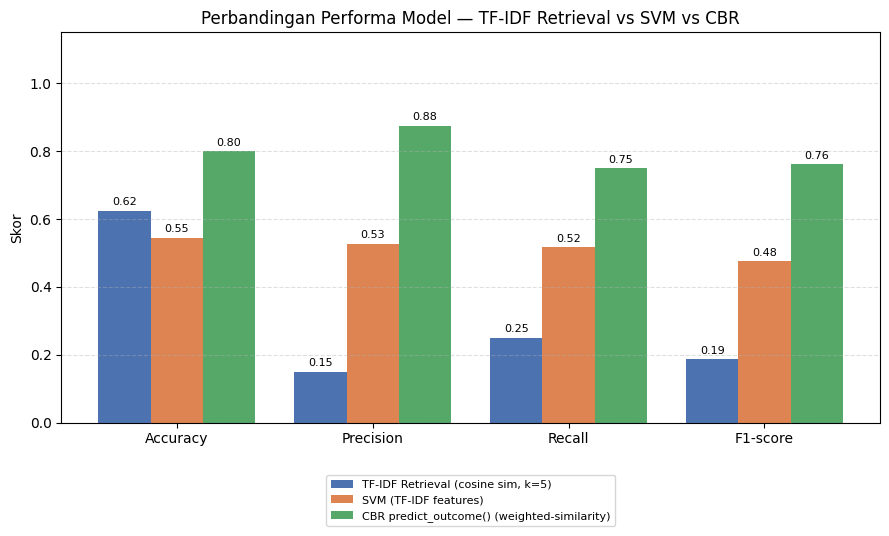

Grafik disimpan -> data/eval/perbandingan_model.png


In [11]:
metrik_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(metrik_cols))
width = 0.8 / len(df_tabel_model)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (_, row) in enumerate(df_tabel_model.iterrows()):
    nilai = [row[c] for c in metrik_cols]
    offset = (i - (len(df_tabel_model) - 1) / 2) * width
    bars = ax.bar(x + offset, nilai, width, label=row['Model'], color=colors[i % len(colors)])
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.2f}',
                ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Skor')
ax.set_title('Perbandingan Performa Model — TF-IDF Retrieval vs SVM vs CBR')
ax.set_xticks(x)
ax.set_xticklabels(metrik_cols)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
os.makedirs('data/eval', exist_ok=True)
plt.savefig('data/eval/perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

print('Grafik disimpan -> data/eval/perbandingan_model.png')

## Cell 9 - Error Analysis: Kasus Kegagalan (Rejection) & Rekomendasi Perbaikan

Sesuai soal poin **e.ii.3** & **f.ii**: *"Analisis kegagalan model (Rejection) dan rekomendasi
perbaikan."* Dua jenis kegagalan dianalisis:
1. **Retrieval gagal** - query tidak menemukan `ground_truth` di top-k (MISS)
2. **Prediksi gagal** - `predicted_label` tidak sama dengan `label_sebenarnya`/putusan asli

In [12]:
print('=' * 78)
print('  ERROR ANALYSIS 1 — KEGAGALAN RETRIEVAL (MISS @k=5)')
print('=' * 78)

miss_list = [d for d in hasil_retrieval['detail'] if not d['hit']]

if len(miss_list) == 0:
    print('  Tidak ada kegagalan retrieval — seluruh query menemukan >=1 ground_truth di top-5.')
else:
    for m in miss_list:
        print(f"  Query {m['query_id']} — GT seharusnya: {m['ground_truth']}")
        print(f"    Top-5 hasil retrieve(): {m['top_k_result']}")
        # Tampilkan kata kunci dominan untuk SEMUA case_id ground_truth (bisa >1)
        for gt_id in m['ground_truth']:
            gt_row = df[df['case_id'] == gt_id]
            if len(gt_row) > 0 and pd.notna(gt_row.iloc[0].get('top_terms', None)):
                kata_kunci_gt = str(gt_row.iloc[0]['top_terms'])[:80]
                print(f"    Kata kunci dominan {gt_id}: {kata_kunci_gt}")
        print()

print(f'  Total MISS               : {len(miss_list)} / {len(hasil_retrieval["detail"])} query')
print(f'  Rejection Rate (Retrieval): {len(miss_list)/len(hasil_retrieval["detail"])*100:.1f}%')
print('=' * 78)


  ERROR ANALYSIS 1 — KEGAGALAN RETRIEVAL (MISS @k=5)
  Query Q003 — GT seharusnya: ['case_001', 'case_003', 'case_005']
    Top-5 hasil retrieve(): ['case_038', 'case_034', 'case_046', 'case_012', 'case_049']
    Kata kunci dominan case_001: fotokopi, tergugat, penggugat, nomor, tanda, diberi, tanggal, rekonpensi, invoic
    Kata kunci dominan case_003: tergugat, penggugat, puluh, ratus, rupiah, tanggal, juta, lima, kepada, ribu
    Kata kunci dominan case_005: tergugat, penggugat, turut, gugatan, nomor, hukum, putusan, tanggal, kepada, tan

  Query Q004 — GT seharusnya: ['case_005', 'case_006', 'case_009']
    Top-5 hasil retrieve(): ['case_039', 'case_020', 'case_023', 'case_008', 'case_031']
    Kata kunci dominan case_005: tergugat, penggugat, turut, gugatan, nomor, hukum, putusan, tanggal, kepada, tan
    Kata kunci dominan case_006: tergugat, penggugat, turut, kepada, bukti, tanggal, nomor, putusan, gugatan, men
    Kata kunci dominan case_009: tergugat, penggugat, surat, investa

In [13]:
print('=' * 78)
print('  ERROR ANALYSIS 2 — KEGAGALAN PREDIKSI (Label Salah)')
print('=' * 78)

if metrik_cbr is not None:
    df_salah = df_pred[df_pred['predicted_label'] != df_pred['label_sebenarnya']]
    print(f'  CBR predict_outcome() — kasus prediksi MELESET: {len(df_salah)} / {len(df_pred)}')
    print()
    if len(df_salah) == 0:
        print('  Tidak ada kegagalan prediksi pada demo manual Tahap 4 — seluruh prediksi tepat.')
    else:
        for _, row in df_salah.iterrows():
            print(f"  [{row['query_id']}] Prediksi : {row['predicted_label_nama']}  |  "
                  f"Sebenarnya: {LABEL_NAMA.get(row['label_sebenarnya'], '?')}")
            print(f"    Query        : {str(row['query'])[:100]}...")
            print(f"    top_5_case_ids: {row['top_5_case_ids']}")
            print()
    print(f'  Rejection Rate (Prediksi CBR): {len(df_salah)/len(df_pred)*100:.1f}%')
else:
    print('  predictions.csv tidak tersedia -> bagian ini dilewati.')

print('=' * 78)
print()

# ── Confusion Matrix SVM secara visual sederhana ──────────────────────────────
cm_svm = np.array(metrik_svm['confusion_matrix'])
print('Confusion Matrix — SVM (held-out test set):')
print(f"                  Prediksi: Ditolak   Prediksi: Dikabulkan")
print(f"  Aktual Ditolak  :     {cm_svm[0][0]:>3}                {cm_svm[0][1]:>3}")
print(f"  Aktual Dikabulkan:    {cm_svm[1][0]:>3}                {cm_svm[1][1]:>3}")
fp = cm_svm[0][1]
fn = cm_svm[1][0]
print()
print(f'  False Positive (diprediksi Dikabulkan, sebenarnya Ditolak): {fp}')
print(f'  False Negative (diprediksi Ditolak, sebenarnya Dikabulkan): {fn}')

  ERROR ANALYSIS 2 — KEGAGALAN PREDIKSI (Label Salah)
  CBR predict_outcome() — kasus prediksi MELESET: 1 / 5

  [D004] Prediksi : Ditolak/NO  |  Sebenarnya: Dikabulkan
    Query        : tergugat sebagai penyewa ruko tidak membayar uang sewa selama enam bulan berturut turut sesuai perja...
    top_5_case_ids: case_008, case_042, case_012, case_002, case_041

  Rejection Rate (Prediksi CBR): 20.0%

Confusion Matrix — SVM (held-out test set):
                  Prediksi: Ditolak   Prediksi: Dikabulkan
  Aktual Ditolak  :       1                  4
  Aktual Dikabulkan:      1                  5

  False Positive (diprediksi Dikabulkan, sebenarnya Ditolak): 4
  False Negative (diprediksi Ditolak, sebenarnya Dikabulkan): 1


### Rekomendasi Perbaikan

Berdasarkan pola kegagalan di atas, berikut rekomendasi perbaikan untuk iterasi CBR berikutnya:

1. **Jika MISS retrieval terjadi pada kasus dengan kosakata khusus/jarang** (mis. istilah
   hukum yang hanya muncul di satu-dua dokumen) → pertimbangkan menurunkan `min_df` pada
   `TfidfVectorizer` (saat ini `min_df=2`), atau menambah dokumen ke case base agar variasi
   kosakata bertambah (poin **Revisi & Retain**, Tahap 6).

2. **Jika query pendek/ringkas (seperti ringkasan_fakta yang dipotong) gagal menemukan
   dokumen relevan** → TF-IDF sensitif terhadap panjang & variasi kata; pertimbangkan
   pendekatan **embedding semantik (IndoBERT)** sebagai pembanding (sesuai opsi soal
   poin c.i.2), karena embedding lebih tahan terhadap perbedaan kata namun makna serupa
   (sinonim), tidak seperti TF-IDF yang bergantung pada kecocokan kata literal.

3. **Jika False Positive/Negative pada SVM tinggi** (model memprediksi 'Dikabulkan' padahal
   'Ditolak' atau sebaliknya) → kemungkinan disebabkan kemiripan pola bahasa antara kasus
   yang dikabulkan & ditolak sebagian (mis. gugatan ditolak karena alasan formil/kurang pihak,
   bukan karena substansi wanprestasinya lemah). Rekomendasi: tambahkan **fitur terstruktur**
   eksplisit (mis. flag "ada-eksepsi-kurang-pihak", "nilai-gugatan", jumlah bukti) di luar
   representasi teks murni TF-IDF, sebagai fitur tambahan untuk SVM.

4. **Untuk metode CBR (`predict_outcome`)** — jika *Weighted Similarity* dan *Majority Vote*
   sering berbeda hasil pada query yang sama, ini menandakan top-k hasil retrieval cukup
   heterogen (campuran label). Rekomendasi: naikkan nilai `k` secara adaptif, atau terapkan
   ambang batas minimum similarity (mis. tolak prediksi bila similarity tertinggi < 0.1)
   sebagai bentuk *rejection* eksplisit daripada memaksakan prediksi dari kasus yang kurang
   relevan.

5. **Ukuran case base (54 dokumen)** relatif kecil untuk domain hukum yang sangat bervariasi
   alasannya (wanprestasi konstruksi, sewa-menyewa, utang-piutang, dll). Menambah jumlah
   dokumen melalui scraping lanjutan (Tahap 1) akan langsung meningkatkan recall retrieval
   karena lebih banyak kandidat dokumen relevan tersedia untuk tiap subdomain kasus.

## Cell 10 - Simpan `retrieval_metrics.csv` & `prediction_metrics.csv`

Sesuai soal poin **e.iii** / **f**: output evaluasi disimpan ke `data/eval/`.

In [14]:
# ── 1) retrieval_metrics.csv — ringkasan + detail per query, per nilai k ─────
rows_retrieval_csv = []
for k_val in [1, 3, 5, 10]:
    r = eval_retrieval(queries, ground_truth_key='ground_truth', k=k_val)
    for d in r['detail']:
        rows_retrieval_csv.append({
            'k'             : k_val,
            'query_id'      : d['query_id'],
            'ground_truth'  : ', '.join(d['ground_truth']),
            'top_k_result'  : ', '.join(d['top_k_result']),
            'tp'            : d['tp'],
            'precision'     : d['precision'],
            'recall'        : d['recall'],
            'f1'            : d['f1'],
            'hit'           : d['hit'],
            'accuracy_at_k' : r['accuracy'],
            'precision_at_k': r['precision'],
            'recall_at_k'   : r['recall'],
            'f1_at_k'       : r['f1_score'],
        })

df_retrieval_metrics = pd.DataFrame(rows_retrieval_csv)
df_retrieval_metrics.to_csv(PATH_RETRIEVAL_OUT, index=False, encoding='utf-8-sig')

print(f'retrieval_metrics.csv tersimpan -> {PATH_RETRIEVAL_OUT}')
print(f'   {len(df_retrieval_metrics)} baris ({df_retrieval_metrics["query_id"].nunique()} query x 4 nilai k)')
print()

# ── 2) prediction_metrics.csv — ringkasan metrik per model klasifikasi ───────
df_prediction_metrics = df_tabel_model[df_tabel_model['Tugas'] == 'Klasifikasi label putusan'].copy()
df_prediction_metrics = df_prediction_metrics.rename(columns={
    'Model': 'model', 'Accuracy': 'accuracy', 'Precision': 'precision',
    'Recall': 'recall', 'F1-score': 'f1_score', 'n': 'n_samples',
})[['model', 'n_samples', 'accuracy', 'precision', 'recall', 'f1_score']]

# Tambahkan info confusion matrix sebagai kolom terpisah
fp_fn_map = {'SVM (TF-IDF features)': metrik_svm}
if metrik_cbr is not None:
    fp_fn_map['CBR predict_outcome() (weighted-similarity)'] = metrik_cbr

df_prediction_metrics['confusion_matrix'] = df_prediction_metrics['model'].map(
    lambda m: str(fp_fn_map[m]['confusion_matrix']) if m in fp_fn_map else ''
)

df_prediction_metrics.to_csv(PATH_PREDICTION_OUT, index=False, encoding='utf-8-sig')

print(f'prediction_metrics.csv tersimpan -> {PATH_PREDICTION_OUT}')
print(f'   {len(df_prediction_metrics)} baris (1 per model)')
print()
print('Preview prediction_metrics.csv:')
print(df_prediction_metrics.to_string(index=False))


retrieval_metrics.csv tersimpan -> data/eval/retrieval_metrics.csv
   32 baris (8 query x 4 nilai k)

prediction_metrics.csv tersimpan -> data/eval/prediction_metrics.csv
   2 baris (1 per model)

Preview prediction_metrics.csv:
                                      model  n_samples  accuracy  precision  recall  f1_score confusion_matrix
                      SVM (TF-IDF features)         11    0.5455     0.5278  0.5167    0.4762 [[1, 4], [1, 5]]
CBR predict_outcome() (weighted-similarity)          5    0.8000     0.8750  0.7500    0.7619 [[3, 0], [1, 1]]


## Cell 11 - Ringkasan Akhir Tahap 5

In [15]:
print()
print('=' * 62)
print('  RINGKASAN AKHIR TAHAP 5 — MODEL EVALUATION')
print('=' * 62)
print(f'  Case base dievaluasi          : {len(df)} kasus')
print(f'  Jumlah query uji retrieval    : {len(queries)}')
print()
print('  Hasil Retrieval (TF-IDF, k=5):')
print(f'    Accuracy   : {hasil_retrieval["accuracy"]:.4f}')
print(f'    Precision  : {hasil_retrieval["precision"]:.4f}')
print(f'    Recall     : {hasil_retrieval["recall"]:.4f}')
print(f'    F1-score   : {hasil_retrieval["f1_score"]:.4f}')
print()
print('  Hasil Prediksi (Klasifikasi Label Putusan):')
print(f'    SVM (TF-IDF)         : Acc={metrik_svm["accuracy"]:.4f}  F1={metrik_svm["f1_score"]:.4f}')
if metrik_cbr is not None:
    print(f'    CBR (weighted-sim)   : Acc={metrik_cbr["accuracy"]:.4f}  F1={metrik_cbr["f1_score"]:.4f}')
print()
print('  Error Analysis:')
print(f'    Retrieval MISS  : {len(miss_list)}/{len(hasil_retrieval["detail"])} '
      f'({len(miss_list)/len(hasil_retrieval["detail"])*100:.1f}%)')
if metrik_cbr is not None:
    n_salah = (df_pred['predicted_label'] != df_pred['label_sebenarnya']).sum()
    print(f'    Prediksi MELESET: {n_salah}/{len(df_pred)} ({n_salah/len(df_pred)*100:.1f}%)')
print()
print('  Output Tahap 5:')
print(f'    [OK] {PATH_RETRIEVAL_OUT}')
print(f'    [OK] {PATH_PREDICTION_OUT}')
print(f'    [OK] data/eval/perbandingan_model.png (grafik)')
print(f'    [OK] data/eval/queries.json (ground truth retrieval)')
print('=' * 62)
print('  STATUS: TAHAP 5 SELESAI. Seluruh siklus CBR (Tahap 1-5) lengkap.')
print('=' * 62)


  RINGKASAN AKHIR TAHAP 5 — MODEL EVALUATION
  Case base dievaluasi          : 54 kasus
  Jumlah query uji retrieval    : 8

  Hasil Retrieval (TF-IDF, k=5):
    Accuracy   : 0.6250
    Precision  : 0.1500
    Recall     : 0.2500
    F1-score   : 0.1875

  Hasil Prediksi (Klasifikasi Label Putusan):
    SVM (TF-IDF)         : Acc=0.5455  F1=0.4762
    CBR (weighted-sim)   : Acc=0.8000  F1=0.7619

  Error Analysis:
    Retrieval MISS  : 3/8 (37.5%)
    Prediksi MELESET: 1/5 (20.0%)

  Output Tahap 5:
    [OK] data/eval/retrieval_metrics.csv
    [OK] data/eval/prediction_metrics.csv
    [OK] data/eval/perbandingan_model.png (grafik)
    [OK] data/eval/queries.json (ground truth retrieval)
  STATUS: TAHAP 5 SELESAI. Seluruh siklus CBR (Tahap 1-5) lengkap.
